# Homework 1 Part 1

This is an individual assignment.

---

Write your answers in markdown cells. You may embed your handwritten work as pictures (preferred method) or push a pdf with all your handwritten answers.

---

# Exercise 1 (3 points)

> **The Bias-Variance Trade-Off**
>
> In model evaluation, **bias** refers to error introduced by overly simplistic assumptions, which can cause **underfitting**, while **variance** refers to sensitivity to fluctuations in the training data, which can cause **overfitting**. **High-bias** models may perform poorly on both training and validation data, whereas **high-variance** models may fit training data very well but generalize poorly to unseen data. Cross-validation helps reveal and balance these effects by testing the model on multiple splits of the data.

**You are fitting a polynomial regression model to data generated by $t=f(x) + \epsilon$, where $f(x)$ is smooth and $\epsilon\sim \mathcal{G}(0,\sigma^2)$. Consider two candidate models:**

* **Model A: Degree-3 polynomial, estimated training MSE = 2.1, estimated 10-fold CV MSE = 2.4.**

* **Model B: Degree-12 polynomial, estimated training MSE = 0.8, estimated 10-fold CV MSE = 3.1.**

1. (1.5 points) **Explain which model exhibits higher variance and why.**

2. (1.5 points) **Which model would you deploy? Justify your choice using the bias–variance trade-off and any other relevant principles.**

Higher variance: Model B (degree 12).
It fits the training data much more tightly (MSE 0.8) but its error jumps on cross-validation (MSE 3.1).

 The large train–CV gap indicates the model is sensitive to the particular training sample—classic high variance/overfitting. The greater complexity (many parameters) amplifies this sensitivity.

Deploy: Model A (degree 3).
Its CV MSE (2.4) is substantially lower than Model B’s (3.1), so it generalizes better. Even if Model A has a bit more bias (higher training MSE than B), it achieves a better bias–variance trade-off: modest complexity, smaller train–CV gap, and performance consistent with a smooth underlying f(x)


---

# Exercise 2 (2.5 points)

**You fit ridge regression with $\lambda\in\{0.01, 0.1, 1, 10\}$ using 5-fold cross-validation. The table below lists the mean absolute error on each fold.**

|Fold | 0.01 | 0.1 | 1 | 10 |
| -- | -- | -- | -- | -- |
|1 | 1.9 | 1.8 | 1.7 | 2.0 |
|2 | 2.0 | 2.0 | 1.8 | 2.2 |
|3 | 2.1 | 2.5 | 2.6 | 2.4 |
|4 | 2.2 | 1.9 | 1.9 | 2.1 |
|5 | 2.3 | 2.1 | 1.8 | 2.3 |

1. (1 point) **Pick the best $\lambda$ using the average validation error.**

2. (1 point) **Pick the best $\lambda$ using the min–max strategy (i.e. maximize worst-case performance).**

3. (0.5 pointt) **Briefly discuss the trade-offs between these two strategies.**

1.   The best $\lambda$ is 1

$\lambda$ = 0.01 , average=2.1

$\lambda$ = 0.1 , average=2.06

$\lambda$ = 1 , average=1.96(smallest)

$\lambda$ = 10 , average=2.2



2. The best $\lambda$ is 0.01

$\lambda$ = 0.01 , Max=2.3(smallest)

$\lambda$ = 0.1 , Max=2.5

$\lambda$ = 1 , Max=2.6

$\lambda$ = 10 , Max=2.4


3. The average-error strategy aims for the best overall expected performance but may suffer in worst-case folds.

     The min–max strategy provides more robust, conservative performance by guarding against bad cases, but often sacrifices the lowest possible average error.

---

# Exercise 3 (7.5 points)

**Suppose you have a training set with $N$ data points $\{x_i\}_{i=1}^N$, where $x_i\in\mathbb{R}^+$ (set of positive real numbers). Assume the samples are independent and identically distributed (i.i.d.), and each sample is drawn from a Gamma random variable with probability density function:**

\begin{align*}
    p(x|\alpha, \beta) = \frac{\beta^{\alpha}}{\Gamma(\alpha)}x^{\alpha-1}e^{-\beta x}
\end{align*}

**where $\alpha,\beta>0$.**

**Moreover, consider another Gamma density as the prior probability on the hyperparameter $\beta$,**

\begin{align*}
    p(\beta|a,b) = \frac{b^a}{\Gamma(a)}\beta^{a-1}e^{-b \beta}
\end{align*}

**where $a,b>0$.**

**Answer the following questions:**

1. (2.5 points) **Derive the maximum likelihood estimate (MLE) for the parameter $\beta$. Show your work.**

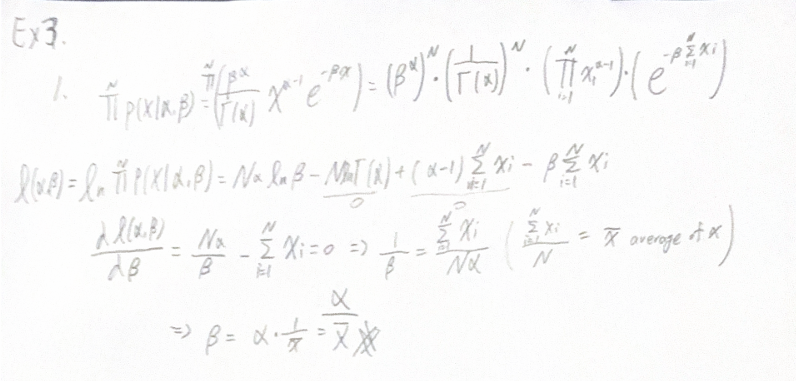

2. (2.5 points) **Derive the maximum a posteriori (MAP) estimate for the parameter $\beta$. show your work.**

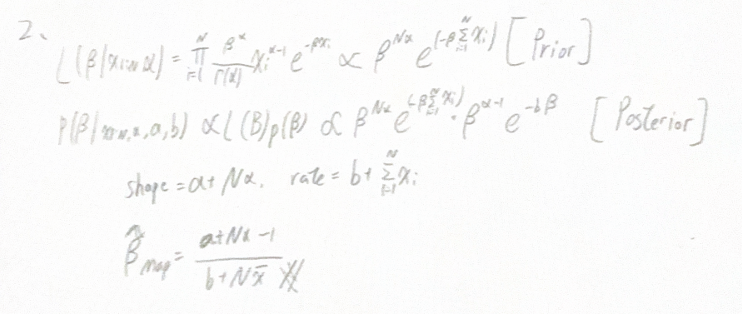

3. (2.5 points) **Does a Gamma-Gamma form a conjugate prior for the parameter $\beta$? Why or why not? If yes, write down the pseudo-code for the online update of the prior parameters (including the equations for the new parameters of the prior). Justify with your own work.**

Yes. A Gamma prior on the rate $\beta$ is conjugate to the Gamma likelihood when $\alpha$ is known.

In [ ]:
"""for each  x in data_stream:
    # update prior → posterior (which becomes next prior)
    a = a + alpha
    b = b + x

    # optional: compute posterior summaries
    post_mean = a / b
    if a > 1:
        post_mode = (a - 1) / b
    else:
        post_mode = 0  # mode at boundary
    post_var = a / (b * b)"""


'for each  x in data_stream:\n    # update prior → posterior (which becomes next prior)\n    a = a + alpha\n    b = b + x\n\n    # optional: compute posterior summaries\n    post_mean = a / b\n    if a > 1:\n        post_mode = (a - 1) / b\n    else:\n        post_mode = 0  # mode at boundary\n    post_var = a / (b * b)'

---

# Exercise 4 (7.5 points)

**An electronics engineer is testing a batch of microchips. Each microchip either works correctly (success or 1) or fails (failure or 0) when powered on. Let $x_i\in\{0,1\}$ represent whether microship $i$ is working. Suppose the engineer tests $N$ microchips from the batch, and the probability that a single microchip works correctly is $p$.**

**Answer the following questions:**
1. (2 points) **Which random variable (RV) best describes this data (assumme $x_i$'s, are i.i.d.)? For your choice of RV, write down the observed data likelihood, $\mathcal{L}$.**

Each $x_i$ is a Bernoulli( $p$ ) random variable

$\mathcal{L}(p \mid x_{1:N}) \;=\; p^{\sum_{i=1}^N x_i}\,(1-p)^{\,N-\sum_{i=1}^N x_i}$


2. (3 points) **Assume the prior $p\sim\text{Beta}(\alpha,\beta)$, i.e.**

$$P(p|\alpha, \beta)=\frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}p^{\alpha-1}(1-p)^{\beta-1}$$

**Derive the MAP estimate of $p$**.

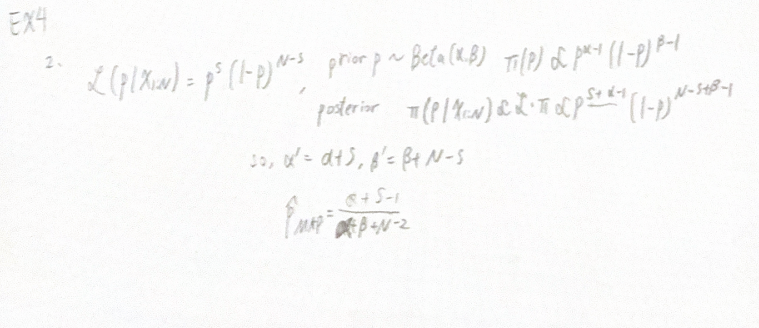

3. (1 point) **Provide the sequential update equations for $\alpha$ and $\beta$.**

Since the prior is p∼Beta(α,β), after observing new Bernoulli data you just increment the hyperparameters according to whether the outcome was success (1) or failure (0).

If the new observation is a success (x=1): α←α+1

If the new observation is a failure (x=0): β←β+1

4. (1 points) **If $\alpha=2$, $\beta=3$, $N=20$, and 11 microships were working correctly, compute the posterior mean of $p$.**

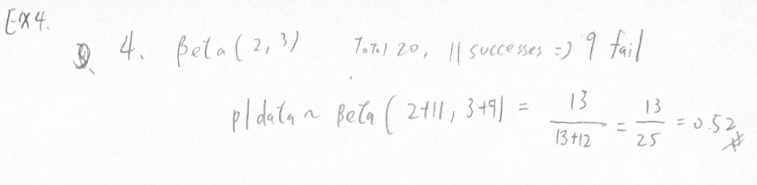

---

# Exercise 5 (7.5 points)

**Suppose you have a training set with $N$ data points $\{x_i\}_{i=1}^N$ with $x_i\in \mathbb{R}$. Assume the samples are independent and identically distributed (i.i.d.), and each sample is drawn from a (univariate) Gaussian density function with _known_ variance $\sigma^2$, i.e. $P(x|\mu) \sim \mathcal{N}(\mu,\sigma^2)$.**

**Consider another Gaussian density function as the prior probability on the mean $\mu$ parameter, $P(\mu) \sim \mathcal{N}(\mu_0,\sigma_0^2)$.**

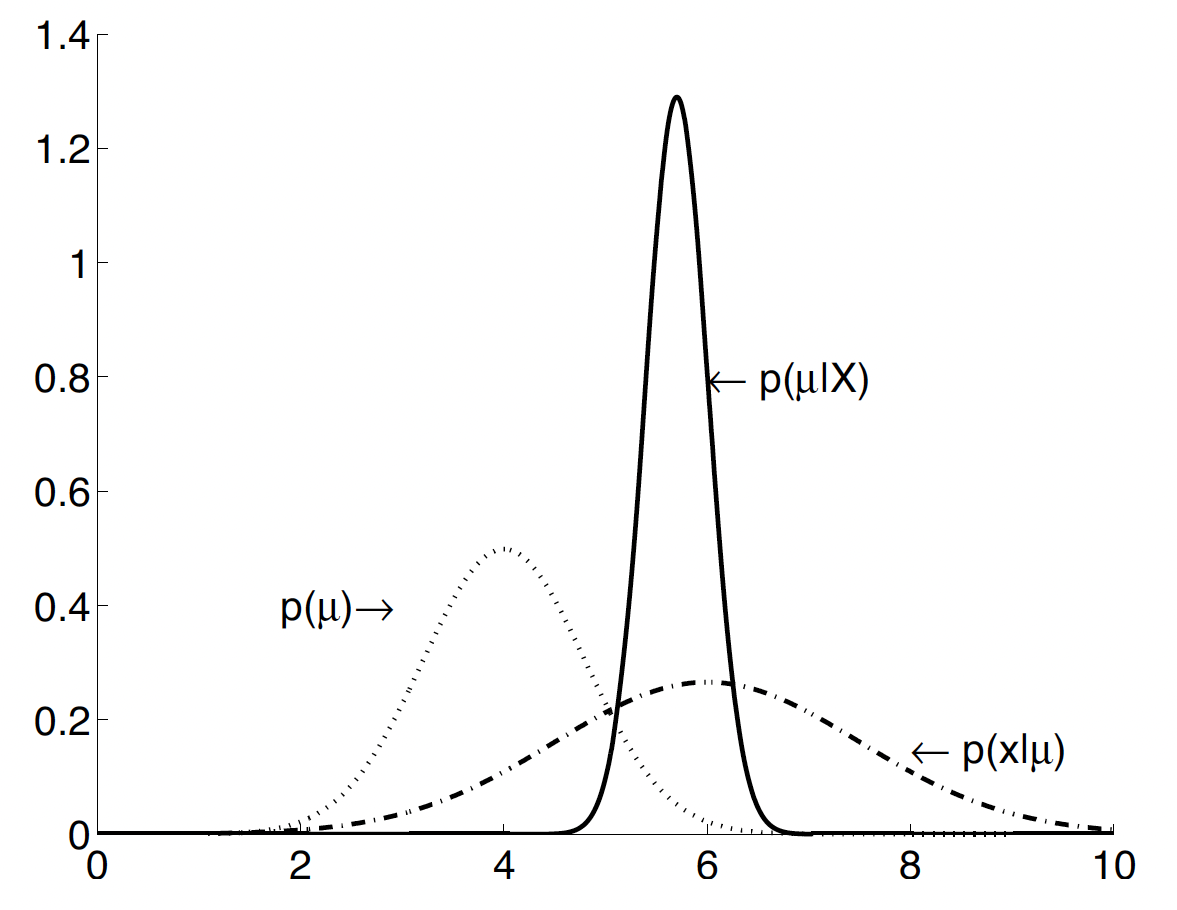

In [ ]:
from IPython.display import Image
Image('figures/parameter_estimation.png', width=450)

**Assume $P(x|\mu) \sim \mathcal{N}(\mu=6,\sigma^2=1.5^2)$ and $P(\mu) \sim \mathcal{N}(\mu_0=4,\sigma_0^2=0.8^2)$, ant the resulting posterior probability on $\mu$ to be $p(\mu|x)\sim\mathcal{N}(5.7, 0.3^2)$. The figure above illustrates all distributions involved.**

**Answer the following questions:**
1. (2.5 points) **Based on the information provided, what is the value of $\mu$ that _should_ be selected using the MAP approach?**

$μ$=5.7

The posterior is given as $p(\mu|x)\sim\mathcal{N}(5.7, 0.3^2)$

For a Gaussian posterior, the mode (MAP) equals the mean, so the MAP estimate is the posterior mean 5.7.

2. (2.5 points) **How would the solution for $\mu$ (from (1)) change as $\sigma_0$ becomes very small?**

When $\sigma_0$ becomes very small, the MAP estimate of $\mu$ will be pulled strongly towards the prior mean $\mu_0$ essentially ignoring the data.

3. (2.5 points) **How would the solution for $\mu$ (from (1)) change as $\sigma_0$ becomes very large?**

As $\sigma_0$ becomes very large, the prior becomes uninformative, and the MAP estimate reduces to the sample mean (the same as the MLE).

---

# Exercise 6 (3 points)

**The figure below, shows how the weights associated with each with the 10 attributes/features change as a function of the regularizer parameter $\lambda$ in a linear regression model.**

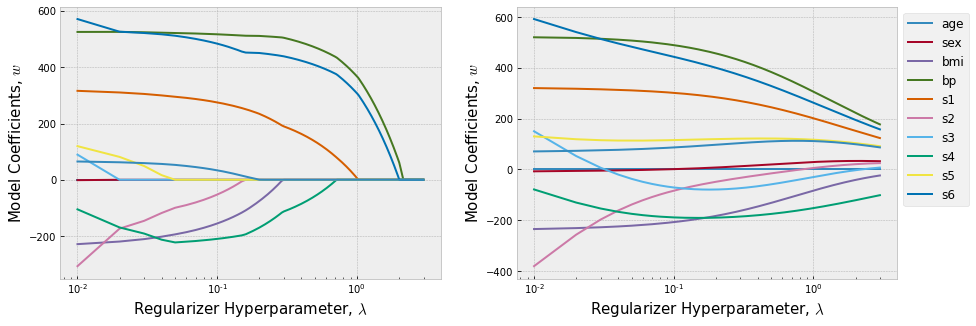

In [ ]:
from IPython.display import Image
Image('figures/Regression_with_Regularizer.png', width=900)

**Based on this plots, which one (left or right) corresponds to the Ridge Regression and Lasso Regression? Justify your answer.**

left is lasso, right is ridge

Because lasso will make the parameters into zero, but ridge only make the parameters close to zero

---

# Exercise 7 (2 points)

**In practice, when you are implementing your regression or classification tasks with your feature matrix $\mathbf{X}$ of size $N\times M$, $N$ is the number of training samples and $M$ is the number of dimensions/features.**

**If you encounter the computational error "matrix is singular":**

1. (1 point) **What does this mean about the feature matrix $\mathbf{X}$?**
2. (1 point) **What should you do to solve the problem?**

It means X has linearly dependent columns, so XTX is singular (non-invertible).

To fix it, you can remove redundant features, use regularization (e.g., ridge regression), or reduce feature dimensionality (e.g., PCA).

---

# Exercise 8 (2 points)

**Before feeding the data to a mapper function, we must carry any necessary preprocessing. This may include encoding features, dealing with missing values, and scaling. In which order should the data be processed:**

* **Option 1: Partition the data into training-test sets, then apply preprocessing based on training set.**

* **Option 2: Apply preprocessing on entire data, then partition into training-test sets.**

Partition the data into training–test sets, then apply preprocessing based on the training set.

Because If you preprocess the entire dataset before splitting (Option 2), information from the test set leaks into the training process (data leakage).

---

# Exercise 9 (4 points)

**Answer the following questions:**

1. (1 point) **Interpret an L2-penalty as a Bayesian prior.**

2. (1 point) **Describe how this perspective enables online updating.**

3. (1 point) **State one advantage for hyperparameter selection.**

4. (1 point) **Give a real-world example where sampling from the posterior is preferable to a point estimate.**

1. **L2 penalty as Bayesian prior:**
   
   The L2 penalty $\lambda \|\mathbf{w}\|^2$ corresponds to placing a Gaussian prior on the parameters: $p(\mathbf{w}) = \mathcal{N}(\mathbf{0}, \frac{1}{\lambda}\mathbf{I})$. The larger $\lambda$ is, the smaller the prior variance, meaning we believe the parameters should be close to zero.

2. **Online updating:**
   
   In the Bayesian framework, today's posterior becomes tomorrow's prior. When new data arrives, we can update our beliefs about $\mathbf{w}$ sequentially:
   
   $$p(\mathbf{w}|\text{old data, new data}) \propto p(\text{new data}|\mathbf{w}) \cdot p(\mathbf{w}|\text{old data})$$
   
   This enables incremental learning without reprocessing all historical data.

3. **Hyperparameter selection advantage:**
   
   The regularization parameter $\lambda$ has a clear interpretation as the precision (inverse variance) of the prior. This enables principled hyperparameter selection using methods like marginal likelihood maximization or cross-validation with proper uncertainty quantification.

4. **Real-world sampling example:**
   
   **Medical diagnosis:** When predicting disease risk, a point estimate might give "70% probability of disease" but sampling from the posterior reveals the uncertainty around this estimate. If the 95% credible interval is [65%, 75%] vs [20%, 95%], this dramatically affects treatment decisions. The uncertainty quantification helps doctors make more informed decisions about additional testing or treatment protocols.

---

# Exercise 10 (6 points)

**Consider a labeled training set $\{(x_i,t_i)\}_{i=1}^N$, where $x_i\in\mathbb{R}$ and $t_i\in\mathbb{R}$. Let the data likelihood on $t_i$ be a univariate Gaussian distribution, that is,**

\begin{align*}
P(t_i|\mathbf{w}) \sim G(t_i | y_i, 1)\;\; \text{ where }\;\; y_i=y(x_i)=\phi(x_i)^T\mathbf{w}
\end{align*}

**Consider the prior probability on parameter $\mathbf{w}$ to be a multivariate Gaussian distributed with mean $\mathbf{0}$ and isotropic covariance matrix $\beta^2\mathbf{I}$. Find the MAP solution for the parameter $\mathbf{w}$. Show your work.**

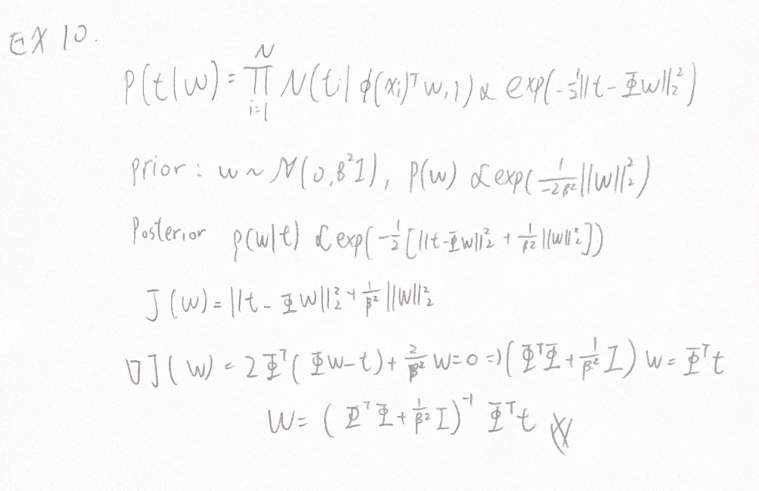

---

# On-Time (5 points)

Submit your assignment before the deadline.

___

# Submit Your Solution

Confirm that you've successfully completed the assignment.

Along with the Notebook, include a PDF of the notebook with your solutions.

```add``` and ```commit``` the final version of your work, and ```push``` your code to your GitHub repository.

Submit the URL of your GitHub Repository as your assignment submission on Canvas.

___